In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from helper.plot import plot_prof
import scipy
from scipy.optimize import curve_fit
from scipy.special import erfc
from collections import defaultdict

In [2]:
# load data (mac)
depth_df = pd.read_csv('/Users/isaac/Library/CloudStorage/OneDrive-UHN/vis_test (caprese) results/vis_x.csv', dtype = float)
time_df = pd.read_csv('/Users/isaac/Library/CloudStorage/OneDrive-UHN/vis_test (caprese) results/vis_time.csv', dtype = float)
conc_df = pd.read_csv('/Users/isaac/Library/CloudStorage/OneDrive-UHN/vis_test (caprese) results/vis_conc_xt.csv', dtype = float)

In [ ]:
# load data (uhn pc)
depth_df = pd.read_csv('C:\Users\t139116uhn\OneDrive - UHN\vis_test (caprese) results\vis_x.csv', dtype = float)
time_df = pd.read_csv('C:\Users\t139116uhn\OneDrive - UHN\vis_test (caprese) results\vis_time.csv', dtype = float)
conc_df = pd.read_csv('C:\Users\t139116uhn\OneDrive - UHN\vis_test (caprese) results\vis_conc_xt.csv', dtype = float)

In [4]:
# convert to np arrayx
depth = np.asarray(depth_df, dtype = float).flatten()
time = np.asarray(time_df, dtype = float).flatten()
conc = np.asarray(conc_df, dtype = float)

# Experimental Profile

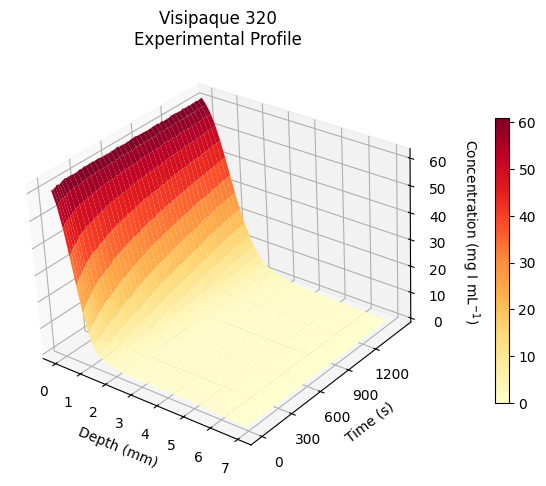

In [5]:
fig, ax = plt.subplots(1, 1, subplot_kw = {"projection": "3d"}, figsize = (6, 6), squeeze = False)
ax = ax.flatten()

depth_mesh, time_mesh = np.meshgrid(depth, time)

plot_prof(fig, ax, 0, x = depth_mesh, y = time_mesh, z = conc, 
          name = "Visipaque 320\nExperimental Profile", 
          elem = "I")
plt.tight_layout()
plt.show()

# Model Fitting
$$C(x,t) = C_s\cdot\operatorname{erfc}\left(\frac{x}{2\sqrt{Dt}}\right)$$

In [6]:
# Diffusion model
def diff_profile(x, d, cs, t):
    """Analytical solution to Fick's second law of diffusion."""
    return cs * (erfc(x / (2.0 * np.sqrt(d * t))))

## 1. Free D and Cs

In [7]:
def diff_free(c_xt, x, time,
              fit_indices=None,
              d_init=1e-4,
              min_points=3):
    T, X = c_xt.shape
    d_per_t = np.full(T, np.nan)
    cs_per_t = np.full(T, np.nan)
    r2_per_t = np.full(T, np.nan)
    se_d_per_t = np.full(T, np.nan)
    se_cs_per_t = np.full(T, np.nan)
    lb_d_per_t = np.full(T, np.nan)
    ub_d_per_t = np.full(T, np.nan)
    lb_cs_per_t = np.full(T, np.nan)
    ub_cs_per_t = np.full(T, np.nan)
    corr_per_t = {}

    if fit_indices is None:
        fit_indices = range(1, T)

    alpha = 0.05

    print("--------")
    print("Reporting Results")
    print("--------")
    
    for i in fit_indices:
        t_i = time[i]
        if t_i <= 0:
            continue

        c_profile = c_xt[i, :]
        mask_valid = np.isfinite(c_profile)
        x_fit = x[mask_valid].flatten()
        c_fit = c_profile[mask_valid].flatten()

        if len(x_fit) < min_points:
            print(f"t = {t_i}: {len(x_fit)} points valid. Skipping.")
            continue

        p0 = [d_init, np.nanmax(c_fit)]
        lower = [0, 0]
        upper = [np.inf, np.inf]

        def model(x_seg, D, Cs):
            return diff_profile(x_seg, D, Cs, t_i)
        
        try:
            popt, pcov = curve_fit(
                model,
                x_fit, c_fit,
                p0=p0,
                bounds=(lower, upper)
            )

            D_fit, Cs_fit = popt

            # pcov diagnostics
            if np.any(np.diag(pcov) < 0):
                print(f"t = {t_i}: WARNING: Negative variance in pcov.")
            if np.any(~np.isfinite(pcov)):
                print(f"t = {t_i}: WARNING: pcov contains inf/nan.")

            stdevs = np.sqrt(np.diag(pcov))
            n_obs = len(c_fit)
            df = max(0, n_obs - 2)
            tval = scipy.stats.t.ppf(1.0 - alpha / 2.0, df)
            ci = tval * stdevs

            # Store results
            d_per_t[i] = D_fit
            cs_per_t[i] = Cs_fit
            se_d_per_t[i] = stdevs[0]
            se_cs_per_t[i] = stdevs[1]
            lb_d_per_t[i] = popt[0] - ci[0]
            ub_d_per_t[i] = popt[0] + ci[0]
            lb_cs_per_t[i] = popt[1] - ci[1]
            ub_cs_per_t[i] = popt[1] + ci[1]

            # Correlation matrix (2x2 for D and Cs)
            with np.errstate(invalid='ignore'):
                corr_per_t[i] = pcov / np.outer(stdevs, stdevs)

            # R2
            c_pred = diff_profile(x_fit, D_fit, Cs_fit, t_i)
            ss_res = np.sum((c_fit - c_pred) ** 2)
            ss_tot = np.sum((c_fit - np.mean(c_fit)) ** 2)
            r2_per_t[i] = 1 - (ss_res / ss_tot)

            print(f"t = {t_i} s: "
                  f"D = {D_fit:.3e}, SE = {stdevs[0]:.3e} "
                  f"(95% CI [{lb_d_per_t[i]:.3e}, {ub_d_per_t[i]:.3e}]), "
                  f"Cs = {Cs_fit:.3f}, SE = {stdevs[1]:.3f} "
                  f"(95% CI [{lb_cs_per_t[i]:.3f}, {ub_cs_per_t[i]:.3f}]), "
                  f"R2 = {r2_per_t[i]:.4f}, "
                  f"D-Cs corr = {corr_per_t[i][0, 1]:.3f}")

        except Exception as e:
            print(f"t = {t_i}: Fit FAILED -> {type(e)}: {e}")

    return {
        'd_per_t':     d_per_t,
        'se_d_per_t':  se_d_per_t,
        'cs_per_t':    cs_per_t,
        'se_cs_per_t': se_cs_per_t,
        'r2_per_t':    r2_per_t,
        'lb_d_per_t':  lb_d_per_t,
        'ub_d_per_t':  ub_d_per_t,
        'lb_cs_per_t': lb_cs_per_t,
        'ub_cs_per_t': ub_cs_per_t,
        'corr_per_t':  corr_per_t,   # dict of 2x2 corr matrices keyed by time index
    }

In [8]:
opt_free = diff_free(c_xt = conc, x = depth, time = time)

--------
Reporting Results
--------
t = 10.0 s: D = 3.186e-02, SE = 1.508e-03 (95% CI [2.881e-02, 3.490e-02]), Cs = 65.323, SE = 1.081 (95% CI [63.140, 67.507]), R2 = 0.9910, D-Cs corr = -0.572
t = 20.0 s: D = 1.668e-02, SE = 7.734e-04 (95% CI [1.512e-02, 1.824e-02]), Cs = 65.208, SE = 1.060 (95% CI [63.068, 67.348]), R2 = 0.9913, D-Cs corr = -0.574
t = 30.0 s: D = 1.118e-02, SE = 5.433e-04 (95% CI [1.008e-02, 1.228e-02]), Cs = 65.816, SE = 1.121 (95% CI [63.552, 68.080]), R2 = 0.9905, D-Cs corr = -0.574
t = 40.0 s: D = 8.651e-03, SE = 4.123e-04 (95% CI [7.819e-03, 9.484e-03]), Cs = 65.824, SE = 1.101 (95% CI [63.600, 68.047]), R2 = 0.9908, D-Cs corr = -0.575
t = 50.0 s: D = 7.006e-03, SE = 3.300e-04 (95% CI [6.339e-03, 7.672e-03]), Cs = 66.309, SE = 1.097 (95% CI [64.094, 68.524]), R2 = 0.9910, D-Cs corr = -0.575
t = 60.0 s: D = 5.986e-03, SE = 2.943e-04 (95% CI [5.392e-03, 6.580e-03]), Cs = 66.485, SE = 1.149 (95% CI [64.164, 68.806]), R2 = 0.9901, D-Cs corr = -0.576
t = 70.0 s: D = 

In [9]:
corrfree_per_t = opt_free['corr_per_t']
valid_idx = np.where(np.isfinite(opt_free["cs_per_t"]))[0]

print("--------")
print("D-Cs correlations per timepoint")
print("--------")
corr_summary = {}
pos_corr = {}

for t_idx in valid_idx:
    corr_t = corrfree_per_t[t_idx][0, 1]  # 2x2 matrix, D-Cs is [0,1]
    label = f"t={time[t_idx]}s"
    corr_summary[label] = corr_t
    if abs(corr_t) >= 0.3:
        pos_corr[label] = corr_t

if not pos_corr:
    print("Weak to no correlations detected.")
else:
    print("Moderate to strong correlations detected:")
    for label, val in pos_corr.items():
        print(f"  D vs Cs at {label}: {val:.3f}")

--------
D-Cs correlations per timepoint
--------
Moderate to strong correlations detected:
  D vs Cs at t=10.0s: -0.572
  D vs Cs at t=20.0s: -0.574
  D vs Cs at t=30.0s: -0.574
  D vs Cs at t=40.0s: -0.575
  D vs Cs at t=50.0s: -0.575
  D vs Cs at t=60.0s: -0.576
  D vs Cs at t=70.0s: -0.577
  D vs Cs at t=80.0s: -0.577
  D vs Cs at t=90.0s: -0.578
  D vs Cs at t=100.0s: -0.578
  D vs Cs at t=110.0s: -0.579
  D vs Cs at t=130.0s: -0.580
  D vs Cs at t=150.0s: -0.581
  D vs Cs at t=170.0s: -0.582
  D vs Cs at t=190.0s: -0.583
  D vs Cs at t=210.0s: -0.583
  D vs Cs at t=230.0s: -0.584
  D vs Cs at t=250.0s: -0.585
  D vs Cs at t=270.0s: -0.585
  D vs Cs at t=290.0s: -0.585
  D vs Cs at t=310.0s: -0.586
  D vs Cs at t=330.0s: -0.587
  D vs Cs at t=350.0s: -0.588
  D vs Cs at t=370.0s: -0.588
  D vs Cs at t=390.0s: -0.588
  D vs Cs at t=410.0s: -0.589
  D vs Cs at t=430.0s: -0.590
  D vs Cs at t=450.0s: -0.590
  D vs Cs at t=470.0s: -0.590
  D vs Cs at t=490.0s: -0.590
  D vs Cs at t=51

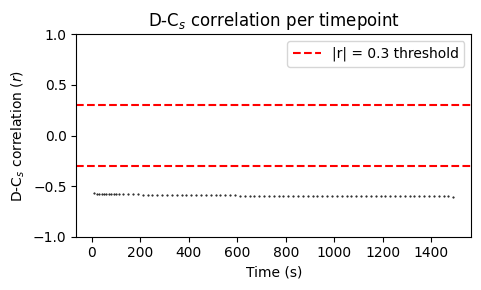

In [10]:
valid_idx = np.where(np.isfinite(opt_free["cs_per_t"]))[0]
dfree_csfree_corrs = [corrfree_per_t[i][0, 1] for i in valid_idx]
t_vals = [time[i] for i in valid_idx]

fig, ax = plt.subplots(figsize = (5, 3))

ax.plot(t_vals, dfree_csfree_corrs,'o', ms = 0.5, mfc = 'k', mec = 'k')
ax.axhline(0.3, color='red', linestyle='--', label='|r| = 0.3 threshold')
ax.axhline(-0.3, color='red', linestyle='--')
ax.set_ylim(-1, 1)
ax.set_xlabel('Time (s)')
ax.set_ylabel(f'D-C$_s$ correlation ($r$)')
ax.set_title(f'D-C$_s$ correlation per timepoint')
ax.legend()
plt.tight_layout()
plt.show()

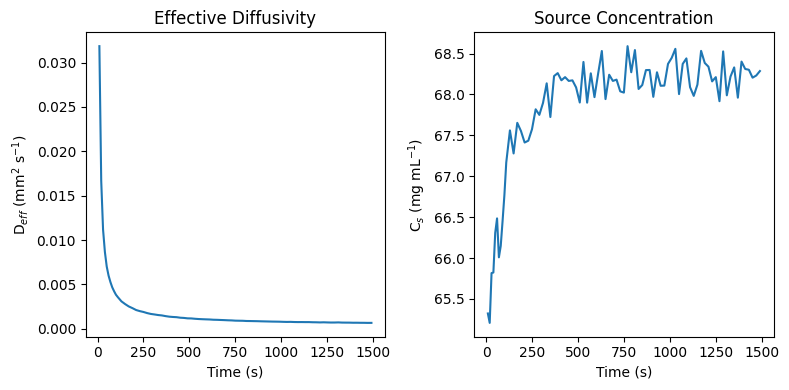

In [11]:
cs_free = opt_free['cs_per_t']
d_free = opt_free['d_per_t']

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (8, 4))
ax[0].plot(time, d_free)
ax[0].set_title(f"Effective Diffusivity")
ax[0].set_ylabel(f'D$_{{eff}}$ (mm$^2$ s$^{{-1}}$)')
ax[0].set_xlabel('Time (s)')
ax[1].plot(time, cs_free)
ax[1].set_title("Source Concentration")
ax[1].set_ylabel(f'C$_s$ (mg mL$^{{-1}}$)')
ax[1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

## 2. Fixed D and Free Cs

In [12]:
def diff_dglobal(c_xt, x, time,
                   c_s = None,
                   fit_indices = None,
                   d_init = 1e-4,
                   min_points = 3):
    T, X = c_xt.shape
    d_global = np.nan
    cs_per_t = np.full(T, np.nan)
    r2_per_t = np.full(T, np.nan)
    se_d = np.nan
    se_cs_per_t = np.full(T, np.nan)
    pcov_out = None
    corr_out = None
    r2_global = np.nan
    lb_all = None
    ub_all = None

    if fit_indices is None:
        fit_indices = range(1, T)

    # Collect valid profiles
    x_segments = []
    c_segments = []
    valid_times = []
    valid_indices = []
    
    for i in fit_indices:
        t_i = time[i]
        if t_i <= 0:
            continue
        c_profile = c_xt[i, :]
        mask_valid = np.isfinite(c_profile)
        x_fit = x[mask_valid]
        c_fit = c_profile[mask_valid]
        if len(x_fit) < min_points:
            print(f"t = {t_i}: {len(x_fit)} points valid.")
            continue
        x_segments.append(x_fit)
        c_segments.append(c_fit)
        valid_times.append(t_i)
        valid_indices.append(i)

    x_all = np.concatenate(x_segments)
    c_all = np.concatenate(c_segments)
    n_t = len(valid_times)

    p0 = [d_init] + [np.nanmax(c) for c in c_segments]
    lower = [0] + [0] * n_t
    upper = [np.inf] + [np.inf] * n_t

    def global_model(x_all, D, *Cs_per_t):
        predicted = []
        for x_seg, t_pred, Cs in zip(x_segments, valid_times, Cs_per_t):
            predicted.append(diff_profile(x_seg, D, Cs, t_pred))
        return np.concatenate(predicted)

    try:
        popt, pcov = curve_fit(
            global_model,
            x_all, c_all,
            p0 = p0,
            bounds = (lower, upper)
        )

        d_global = popt[0]
        cs_values = popt[1:]

        # --- pcov diagnostics ---
        if np.any(np.diag(pcov) < 0):
            print("WARNING: Negative variance in pcov - fit may be ill-conditioned.")
        if np.any(~np.isfinite(pcov)):
            print("WARNING: pcov contains inf/nan - parameters may be unidentifiable.")

        # SE directly from pcov diagonal
        stdevs = np.sqrt(np.diag(pcov))
        se_d = stdevs[0]
        for param_idx, idx in enumerate(valid_indices):
            se_cs_per_t[idx] = stdevs[param_idx + 1]

        # Correlation matrix
        with np.errstate(invalid = "ignore"):
            corr_out = pcov / np.outer(stdevs, stdevs)
        pcov_out = pcov

        # 95%CI for printing only
        alpha = 0.05
        n = len(c_all)
        p = len(popt)
        df = max(0, n - p)
        tval = scipy.stats.t.ppf(1.0 - alpha / 2.0, df)
        ci = tval * stdevs
        lb_all = popt - ci
        ub_all = popt + ci

        # Per-timepoint R2 and Cs
        for param_idx, (idx, x_seg, c_seg, cs, t_fit) in enumerate(
            zip(valid_indices, x_segments, c_segments, cs_values, valid_times)
        ):
            cs_per_t[idx] = cs
            c_pred = diff_profile(x_seg, d_global, cs, t_fit)
            ss_res = np.sum((c_seg - c_pred) ** 2)
            ss_tot = np.sum((c_seg - np.mean(c_seg)) ** 2)
            r2_per_t[idx] = 1 - (ss_res / ss_tot)

        r2_global = np.nanmean(r2_per_t[list(valid_indices)])

        # --- Reporting ---
        print(f"\nGlobal fit complete.")
        print(f"D = {d_global:.3e} mm2/s, SE = {se_d:.3e} (95%CI [{lb_all[0]:.3e}, {ub_all[0]:.3e}]")
        print(f"Note: SE and CI are symmetric (curve_fit linear approximation)")
        for param_idx, (idx, cs, t_fit) in enumerate(
            zip(valid_indices, cs_values, valid_times)
        ):
            lb_cs = lb_all[param_idx + 1]
            ub_cs = ub_all[param_idx + 1]
            print(f"t = {t_fit} s: Cs = {cs:.3f}, SE = {se_cs_per_t[idx]:.3f} (95%CI [{lb_cs:.3f}, {ub_cs:.3f}])")

        print(f"Mean per-timepoint R2 = {r2_global:.4f}")

        # Correlation matrix
        param_labels = ["D"] + [f"Cs_t{i}" for i in range(n_t)]
        print("\nCorrelation matrix:")
        print(f"{'':>10}", end = "")
        for label in param_labels:
            print(f"{label:>10}", end = "")
        print()
        for i, label in enumerate(param_labels):
            print(f"{label:>10}", end = "")
            for j in range(len(param_labels)):
                print(f"{corr_out[i, j]:>10.3f}", end = "")
            print()

    except Exception as e:
        print(f"Global fit FAILED -> {type(e)}: {e}")

    return{
        "d_global": d_global,
        "se_d": se_d,
        "cs_per_t": cs_per_t,
        "se_cs_per_t": se_cs_per_t,
        "r2_per_t": r2_per_t,
        "r2_global": r2_global,
        "pcov": pcov_out,
        "corr": corr_out,
        "lb_all": lb_all,
        "ub_all": ub_all,
    }

In [13]:
opt_dglobal = diff_dglobal(c_xt = conc, x = depth, time = time)


Global fit complete.
D = 1.083e-03 mm2/s, SE = 1.428e-05 (95%CI [1.055e-03, 1.111e-03]
Note: SE and CI are symmetric (curve_fit linear approximation)
t = 10.0 s: Cs = 71.171, SE = 4.228 (95%CI [62.881, 79.461])
t = 20.0 s: Cs = 75.575, SE = 4.001 (95%CI [67.731, 83.419])
t = 30.0 s: Cs = 77.698, SE = 3.826 (95%CI [70.196, 85.200])
t = 40.0 s: Cs = 78.536, SE = 3.689 (95%CI [71.303, 85.770])
t = 50.0 s: Cs = 79.304, SE = 3.577 (95%CI [72.290, 86.318])
t = 60.0 s: Cs = 79.539, SE = 3.483 (95%CI [72.710, 86.368])
t = 70.0 s: Cs = 78.890, SE = 3.402 (95%CI [72.220, 85.560])
t = 80.0 s: Cs = 78.731, SE = 3.330 (95%CI [72.202, 85.261])
t = 90.0 s: Cs = 78.817, SE = 3.267 (95%CI [72.412, 85.223])
t = 100.0 s: Cs = 78.771, SE = 3.210 (95%CI [72.477, 85.064])
t = 110.0 s: Cs = 78.903, SE = 3.158 (95%CI [72.710, 85.095])
t = 130.0 s: Cs = 78.563, SE = 3.067 (95%CI [72.548, 84.577])
t = 150.0 s: Cs = 77.556, SE = 2.990 (95%CI [71.694, 83.417])
t = 170.0 s: Cs = 77.198, SE = 2.922 (95%CI [71.469,

In [14]:
# Correlation coefficient calculation
dglobal_csfree_corr = opt_dglobal['corr']
valid_idx = np.where(np.isfinite(opt_dglobal["cs_per_t"]))[0]

param_labels = ['D'] + [f"Cs_t{i}" for i in valid_idx]

print("--------")
print("D correlations with each CS")
print("--------")

corr_summary = {}
pos_corr = {}

for i, label in enumerate(param_labels[1:]):
    corr_t = dglobal_csfree_corr[0, i + 1]
    corr_summary[label] = corr_t
    if abs(corr_t) >= 0.3: 
        pos_corr[label] = corr_t

if not pos_corr: 
    print("Weak to no correlations detected.")
else:
    for key in pos_corr.keys():
        print("Moderate to strong correlations detected:")
        print(f"D vs {key}: {pos_corr[key]:.3f}")

--------
D correlations with each CS
--------
Weak to no correlations detected.


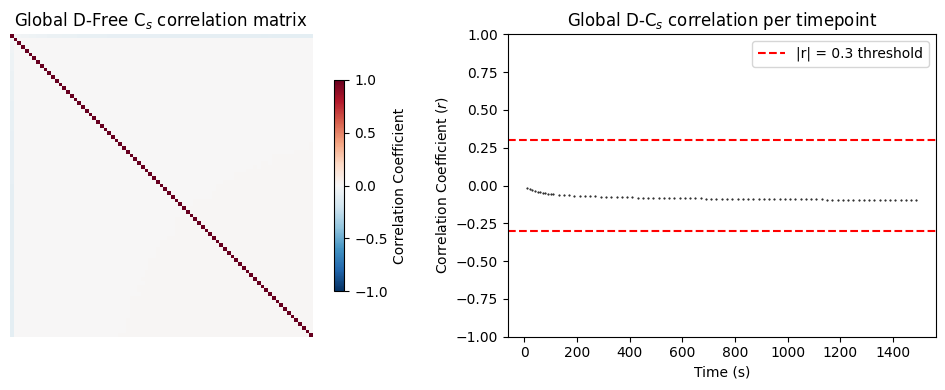

In [15]:
# Plotting
fig, ax = plt.subplots(1, 2, figsize = (10, 4), gridspec_kw = {"width_ratios": [1, 1], "height_ratios": [1]})
# Correlation matrix
im = ax[0].imshow(dglobal_csfree_corr, vmin = -1, vmax = 1, cmap = plt.cm.RdBu_r)
fig.colorbar(im, ax = ax[0], label = "Correlation Coefficient", shrink = 0.7)
ax[0].set_title(f'Global D-Free C$_s$ correlation matrix')
ax[0].set_axis_off()

# Per-timepoint correlation (Global D vs. per-timepoint Cs)
t_vals = [time[i] for i in valid_idx]
ax[1].plot(t_vals, dglobal_csfree_corr[0, 1:], 'o', ms = 0.5, mfc = 'k', mec = 'k')
ax[1].set_ylim(-1, 1)
ax[1].axhline(y = -0.3, linestyle = "--", color = 'r')
ax[1].axhline(y = 0.3, linestyle = "--", color = 'r', label = '|r| = 0.3 threshold')
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel(f"Correlation Coefficient ($r$)")
ax[1].set_title(f"Global D-C$_s$ correlation per timepoint")
ax[1].legend()
plt.tight_layout()
plt.show()

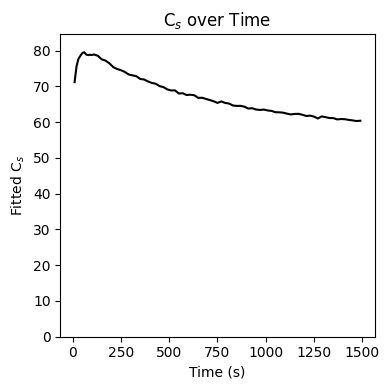

In [16]:
cs_opt = opt_dglobal['cs_per_t']

fig, ax = plt.subplots(figsize = (4, 4))
ax.plot(time, cs_opt, color = 'k')
ax.set_ylim(0, (np.nanmax(cs_opt) + 5))
ax.set_xlabel("Time (s)")
ax.set_ylabel(f"Fitted C$_s$")
ax.set_ylim(0, np.nanmax(cs_opt) + 5)
ax.set_title(f"C$_s$ over Time")
plt.tight_layout()
plt.show()

## 3. Free D and Fixed Cs

In [17]:
def diff_csglobal(c_xt, x, time,
                   c_s = None,
                   fit_indices = None,
                   d_init = 1e-4,
                   min_points = 3):
    T, X = c_xt.shape
    cs_global = np.nan
    d_per_t = np.full(T, np.nan)
    r2_per_t = np.full(T, np.nan)
    se_cs = np.nan
    se_d_per_t = np.full(T, np.nan)
    pcov_out = None
    corr_out = None
    r2_global = np.nan
    lb_all = None
    ub_all = None

    if fit_indices is None:
        fit_indices = range(1, T)

    # Collect valid profiles
    x_segments = []
    c_segments = []
    valid_times = []
    valid_indices = []
    
    for i in fit_indices:
        t_i = time[i]
        if t_i <= 0:
            continue
        c_profile = c_xt[i, :]
        mask_valid = np.isfinite(c_profile)
        x_fit = x[mask_valid]
        c_fit = c_profile[mask_valid]
        
        if len(x_fit) < min_points:
            print(f"t = {t_i}: {len(x_fit)} points valid.")
            continue
            
        x_segments.append(x_fit)
        c_segments.append(c_fit)
        valid_times.append(t_i)
        valid_indices.append(i)

    x_all = np.concatenate(x_segments)
    c_all = np.concatenate(c_segments)
    n_t = len(valid_times)

    p0 = [np.nanmax(c_all)] + [d_init] * n_t
    lower = [0] + [0] * n_t
    upper = [np.inf] + [np.inf] * n_t

    def global_model(x_all, Cs, *D_per_t):
        predicted = []
        for x_seg, t_pred, D in zip(x_segments, valid_times, D_per_t):
            predicted.append(diff_profile(x_seg, D, Cs, t_pred))
        return np.concatenate(predicted)

    try:
        popt, pcov = curve_fit(
            global_model,
            x_all, c_all,
            p0 = p0,
            bounds = (lower, upper)
        )

        cs_global = popt[0]
        d_values = popt[1:]

        # --- pcov diagnostics ---
        if np.any(np.diag(pcov) < 0):
            print("WARNING: Negative variance in pcov - fit may be ill-conditioned.")
        if np.any(~np.isfinite(pcov)):
            print("WARNING: pcov contains inf/nan - parameters may be unidentifiable.")

        # SE directly from pcov diagonal
        stdevs = np.sqrt(np.diag(pcov))
        se_cs = stdevs[0]
        for param_idx, idx in enumerate(valid_indices):
            se_d_per_t[idx] = stdevs[param_idx + 1]

        # Correlation matrix
        with np.errstate(invalid = "ignore"):
            corr_out = pcov / np.outer(stdevs, stdevs)
        pcov_out = pcov

        # 95%CI for printing only
        alpha = 0.05
        n = len(c_all)
        p = len(popt)
        df = max(0, n - p)
        tval = scipy.stats.t.ppf(1.0 - alpha / 2.0, df)
        ci = tval * stdevs
        lb_all = popt - ci
        ub_all = popt + ci

        # Per-timepoint R2 and Cs
        for param_idx, (idx, x_seg, c_seg, d, t_fit) in enumerate(
            zip(valid_indices, x_segments, c_segments, d_values, valid_times)
        ):
            d_per_t[idx] = d
            c_pred = diff_profile(x_seg, d, cs_global, t_fit)
            ss_res = np.sum((c_seg - c_pred) ** 2)
            ss_tot = np.sum((c_seg - np.mean(c_seg)) ** 2)
            r2_per_t[idx] = 1 - (ss_res / ss_tot)

        r2_global = np.nanmean(r2_per_t[list(valid_indices)])

        # --- Reporting ---
        print(f"\nGlobal fit complete.")
        print(f"Cs = {cs_global:.3e} mg/mL, SE = {se_cs:.3e} (95%CI [{lb_all[0]:.3e}, {ub_all[0]:.3e}])")
        print(f"Note: SE and CI are symmetric (curve_fit linear approximation)")
        for param_idx, (idx, d, t_fit) in enumerate(
            zip(valid_indices, d_values, valid_times)
        ):
            lb_cs = lb_all[param_idx + 1]
            ub_cs = ub_all[param_idx + 1]
            print(f"t = {t_fit} s: D = {d:.3e}, SE = {se_d_per_t[idx]:.3e} (95%CI [{lb_cs:.3e}, {ub_cs:.3e}])")

        print(f"Mean per-timepoint R2 = {r2_global:.4f}")

        # Correlation matrix
        param_labels = ["Cs"] + [f"D_t{i}" for i in range(n_t)]
        print("\nCorrelation matrix:")
        print(f"{'':>10}", end = "")
        for label in param_labels:
            print(f"{label:>10}", end = "")
        print()
        for i, label in enumerate(param_labels):
            print(f"{label:>10}", end = "")
            for j in range(len(param_labels)):
                print(f"{corr_out[i, j]:>10.3e}", end = "")
            print()

    except Exception as e:
        print(f"Global fit FAILED -> {type(e)}: {e}")

    return{
        "cs_global": cs_global,
        "se_cs": se_cs,
        "d_per_t": d_per_t,
        "se_d_per_t": se_d_per_t,
        "r2_per_t": r2_per_t,
        "r2_global": r2_global,
        "pcov": pcov_out,
        "corr": corr_out,
        "lb_all": lb_all,
        "ub_all": ub_all,
    }

In [18]:
opt_csglobal = diff_csglobal(c_xt = conc, x = depth, time = time)


Global fit complete.
Cs = 6.792e+01 mg/mL, SE = 1.306e-01 (95%CI [6.766e+01, 6.817e+01])
Note: SE and CI are symmetric (curve_fit linear approximation)
t = 10.0 s: D = 3.000e-02, SE = 1.399e-03 (95%CI [2.726e-02, 3.275e-02])
t = 20.0 s: D = 1.565e-02, SE = 7.219e-04 (95%CI [1.423e-02, 1.706e-02])
t = 30.0 s: D = 1.065e-02, SE = 4.888e-04 (95%CI [9.693e-03, 1.161e-02])
t = 40.0 s: D = 8.242e-03, SE = 3.753e-04 (95%CI [7.506e-03, 8.978e-03])
t = 50.0 s: D = 6.752e-03, SE = 3.057e-04 (95%CI [6.153e-03, 7.351e-03])
t = 60.0 s: D = 5.792e-03, SE = 2.603e-04 (95%CI [5.282e-03, 6.303e-03])
t = 70.0 s: D = 5.038e-03, SE = 2.256e-04 (95%CI [4.595e-03, 5.480e-03])
t = 80.0 s: D = 4.480e-03, SE = 1.998e-04 (95%CI [4.088e-03, 4.872e-03])
t = 90.0 s: D = 4.084e-03, SE = 1.810e-04 (95%CI [3.729e-03, 4.439e-03])
t = 100.0 s: D = 3.737e-03, SE = 1.650e-04 (95%CI [3.414e-03, 4.061e-03])
t = 110.0 s: D = 3.508e-03, SE = 1.536e-04 (95%CI [3.207e-03, 3.809e-03])
t = 130.0 s: D = 3.058e-03, SE = 1.329e-04

In [19]:
# Correlation coefficient calculation
dfree_csglobal_corr = opt_csglobal['corr']
valid_idx = np.where(np.isfinite(opt_csglobal["d_per_t"]))[0]

param_labels = ['Cs'] + [f"D_t{i}" for i in valid_idx]

print("--------")
print("D correlations with each CS")
print("--------")

corr_summary = {}
pos_corr = {}

for i, label in enumerate(param_labels[1:]):
    corr_t = dfree_csglobal_corr[0, i + 1]
    corr_summary[label] = corr_t
    if abs(corr_t) >= 0.3: 
        pos_corr[label] = corr_t

if not pos_corr: 
    print("Weak to no correlations detected.")
else:
    print("Moderate to strong correlations detected:")
    for key in pos_corr.keys():
        print(f"D vs {key}: {pos_corr[key]:.3f}")

--------
D correlations with each CS
--------
Weak to no correlations detected.


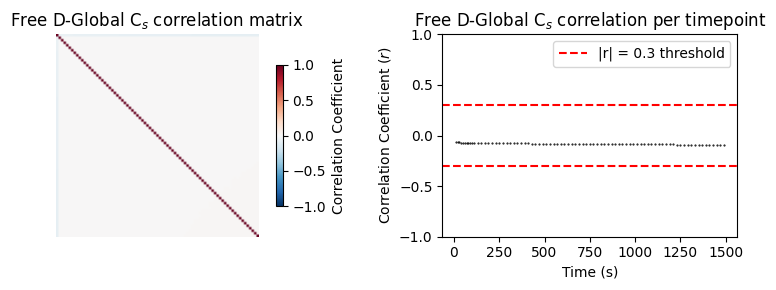

In [20]:
# Plotting
fig, ax = plt.subplots(1, 2, figsize = (8, 3), gridspec_kw = {"width_ratios": [1.2, 1], "height_ratios": [1]})
# Correlation matrix
im = ax[0].imshow(dfree_csglobal_corr, vmin = -1, vmax = 1, cmap = plt.cm.RdBu_r)
fig.colorbar(im, ax = ax[0], label = "Correlation Coefficient", shrink = 0.7)
ax[0].set_title(f'Free D-Global C$_s$ correlation matrix')
ax[0].set_axis_off()

# Per-timepoint correlation (Global D vs. per-timepoint Cs)
t_vals = [time[i] for i in valid_idx]
ax[1].plot(t_vals, dfree_csglobal_corr[0, 1:], 'o', ms = 0.5, mfc = 'k', mec = 'k')
ax[1].set_ylim(-1, 1)
ax[1].axhline(y = -0.3, linestyle = "--", color = 'r')
ax[1].axhline(y = 0.3, linestyle = "--", color = 'r', label = '|r| = 0.3 threshold')
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel(f"Correlation Coefficient ($r$)")
ax[1].set_title(f"Free D-Global C$_s$ correlation per timepoint")
ax[1].legend()
plt.tight_layout()
plt.show()

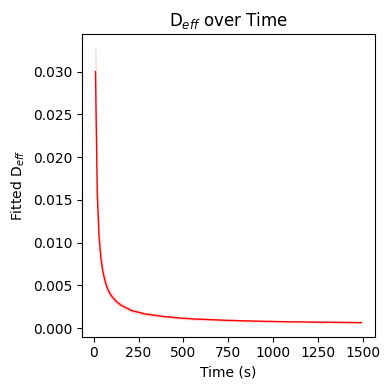

In [21]:
d_opt = opt_csglobal['d_per_t']
d_lb = opt_csglobal['lb_all']
d_ub = opt_csglobal['ub_all']

d_opt[0] = np.nan
d_lb[0] = np.nan
d_ub[0] = np.nan

fig, ax = plt.subplots(figsize = (4, 4))
ax.plot(time, d_opt, color = 'r', lw = 1)
ax.fill_between(time,
               d_lb, d_ub,
               color = 'red',
               alpha = 0.1)
ax.set_xlabel("Time (s)")
ax.set_ylabel(f"Fitted D$_{{eff}}$")
ax.set_title(f"D$_{{eff}}$ over Time")
plt.tight_layout()
plt.show()

## 4. Fixed D and Cs

In [22]:
def diff_global(c_xt, x, time,
                   c_s = None,
                   fit_indices = None,
                   d_init = 1e-4,
                   min_points = 3):
    T, X = c_xt.shape
    cs_global = np.nan
    d_global = np.nan
    r2_per_t = np.full(T, np.nan)
    se_d = np.nan
    se_cs_per_t = np.full(T, np.nan)
    pcov_out = None
    corr_out = None
    r2_global = np.nan
    lb_all = None
    ub_all = None

    if fit_indices is None:
        fit_indices = range(1, T)

    # Collect valid profiles
    x_segments = []
    c_segments = []
    valid_times = []
    valid_indices = []
    
    for i in fit_indices:
        t_i = time[i]
        if t_i <= 0:
            continue
        c_profile = c_xt[i, :]
        mask_valid = np.isfinite(c_profile)
        x_fit = x[mask_valid]
        c_fit = c_profile[mask_valid]
        if len(x_fit) < min_points:
            print(f"t = {t_i}: {len(x_fit)} points valid.")
            continue
        x_segments.append(x_fit)
        c_segments.append(c_fit)
        valid_times.append(t_i)
        valid_indices.append(i)

    x_all = np.concatenate(x_segments)
    c_all = np.concatenate(c_segments)
    n_t = len(valid_times)

    p0 = [np.nanmax(c_fit), d_init]
    lower = [0, 0]
    upper = [np.inf, np.inf]

    def global_model(x_all, Cs, D):
        predicted = []
        for x_seg, t_pred in zip(x_segments, valid_times):
            predicted.append(diff_profile(x_seg, D, Cs, t_pred))
        return np.concatenate(predicted)

    try:
        popt, pcov = curve_fit(
            global_model,
            x_all, c_all,
            p0 = p0,
            bounds = (lower, upper)
        )

        cs_global = popt[0]
        d_global = popt[1]

        # --- pcov diagnostics ---
        if np.any(np.diag(pcov) < 0):
            print("WARNING: Negative variance in pcov - fit may be ill-conditioned.")
        if np.any(~np.isfinite(pcov)):
            print("WARNING: pcov contains inf/nan - parameters may be unidentifiable.")

        # SE directly from pcov diagonal
        stdevs = np.sqrt(np.diag(pcov))
        se_cs = stdevs[0]
        se_d = stdevs[1]

        # Correlation matrix
        with np.errstate(invalid = "ignore"):
            corr_out = pcov / np.outer(stdevs, stdevs)
        pcov_out = pcov

        # 95%CI for printing only
        alpha = 0.05
        n = len(c_all)
        p = len(popt)
        df = max(0, n - p)
        tval = scipy.stats.t.ppf(1.0 - alpha / 2.0, df)
        ci = tval * stdevs
        lb_all = popt - ci
        ub_all = popt + ci

        # Per-timepoint R2
        for param_idx, (idx, x_seg, c_seg, t_fit) in enumerate(
            zip(valid_indices, x_segments, c_segments, valid_times)
        ):
            c_pred = diff_profile(x_seg, d_global, cs_global, t_fit)
            ss_res = np.sum((c_seg - c_pred) ** 2)
            ss_tot = np.sum((c_seg - np.mean(c_seg)) ** 2)
            r2_per_t[idx] = 1 - (ss_res / ss_tot)

        r2_global = np.nanmean(r2_per_t[list(valid_indices)])

        # --- Reporting ---
        print(f"\nGlobal fit complete.")
        print(f"D = {d_global:.3e}, Cs = {cs_global:.3e} mg/mL, SE = {se_cs:.3e} (95%CI [{lb_all[0]:.3e}, {ub_all[0]:.3e}]")
        print(f"Note: SE and CI are symmetric (curve_fit linear approximation)")

        print(f"Mean per-timepoint R2 = {r2_global:.4f}")

        # Correlation matrix
        param_labels = ["Cs"] + ['D']
        print("\nCorrelation matrix:")
        print(f"{'':>10}", end = "")
        for label in param_labels:
            print(f"{label:>10}", end = "")
        print()
        for i, label in enumerate(param_labels):
            print(f"{label:>10}", end = "")
            for j in range(len(param_labels)):
                print(f"{corr_out[i, j]:>10.3e}", end = "")
            print()

    except Exception as e:
        print(f"Global fit FAILED -> {type(e)}: {e}")

    return{
        "cs_global": cs_global,
        "se_d": se_d,
        "d_global": d_global,
        "se_cs_per_t": se_cs_per_t,
        "r2_per_t": r2_per_t,
        "r2_global": r2_global,
        "pcov": pcov_out,
        "corr": corr_out,
        "lb_all": lb_all,
        "ub_all": ub_all,
    }

In [23]:
opt_global = diff_global(c_xt = conc, x = depth, time = time)


Global fit complete.
D = 1.022e-03, Cs = 6.677e+01 mg/mL, SE = 3.312e-01 (95%CI [6.612e+01, 6.742e+01]
Note: SE and CI are symmetric (curve_fit linear approximation)
Mean per-timepoint R2 = 0.9217

Correlation matrix:
                  Cs         D
        Cs 1.000e+00-5.903e-01
         D-5.903e-01 1.000e+00


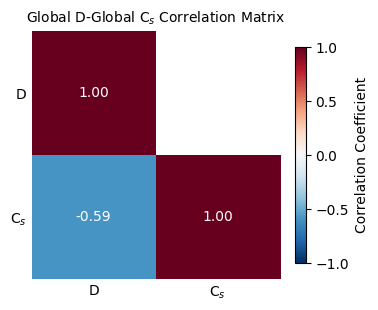

In [24]:
# Plotting correlation matrix
dglobal_csglobal_corr = opt_global['corr']
labels = ["D", f"C$_s$"]

# Mask upper triangle
mask = np.triu(np.ones_like(dglobal_csglobal_corr, dtype = bool), k = 1)

# Apply mask
masked_corr = np.ma.masked_where(mask, dglobal_csglobal_corr)

fig, ax = plt.subplots(figsize = (4, 4))
im = ax.imshow(masked_corr, vmin = -1, vmax = 1, cmap = plt.cm.RdBu_r)
fig.colorbar(im, ax = ax, label = 'Correlation Coefficient', shrink = 0.7)
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.tick_params(length = 0)

# add values to cells
for i in range(masked_corr.shape[0]):
    for j in range(masked_corr.shape[1]):
        if not mask[i, j]:
            ax.text(
                j, i,
                f"{dglobal_csglobal_corr[i, j]:.2f}",
                ha = 'center',
                va = 'center',
                color = 'white'
            )

# Remove border box
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(f"Global D-Global C$_s$ Correlation Matrix", fontdict = {"size": 10})
plt.show()

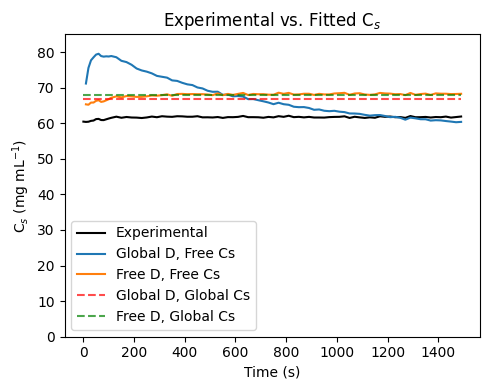

In [25]:
# Cs values
first_row = conc[:, 0] # experimental
cs_dfixed = opt_dglobal['cs_per_t']
cs_dfree = opt_csglobal['cs_global']
cs_free = opt_free['cs_per_t']
cs_glob = opt_global['cs_global']

fig, ax = plt.subplots(figsize = (5, 4))
ax.plot(time, first_row, label = 'Experimental', color = 'k')
ax.plot(time, cs_dfixed, label = 'Global D, Free Cs')
ax.plot(time, cs_free, label = 'Free D, Free Cs')
ax.hlines(y = cs_glob, xmin = np.nanmin(time), xmax = np.nanmax(time), 
          label = 'Global D, Global Cs', 
          color = 'red', linestyle = '--', alpha = 0.7)
ax.hlines(y = cs_dfree, xmin = np.nanmin(time), xmax = np.nanmax(time), 
          label = 'Free D, Global Cs', 
          color = 'green', linestyle = '--', alpha = 0.7)
ax.legend()
ax.set_ylim(0, 85)
ax.set_title(f"Experimental vs. Fitted C$_s$")
ax.set_xlabel("Time (s)")
ax.set_ylabel(f"C$_s$ (mg mL$^{{-1}})$")

plt.tight_layout()
plt.show()

# Sensitivity Analyses

## 1. Fixing Cs to experimental Cs 
- Cs is consistently overestimated when compared to *experimental* Cs
- Negative correlation in most fittings - Cs overestimated and D underestimated
- May be due to profile in earlier timepoints being too steep -> unable to fit properly
- Due to these, D is not actually time-varying, but constant.

In [26]:
def diff_csfixed(c_xt, x, time,
                   cs_fixed, # scalar (global) or array of length T (per-timepoint)
                   fit_indices = None,
                   d_init = 1e-4,
                   min_points = 3):
    T, X = c_xt.shape
    d_global = np.nan
    d_per_t = np.full(T, np.nan)
    r2_per_t = np.full(T, np.nan)
    se_d_global = np.nan
    se_d_per_t = np.full(T, np.nan)
    lb_d_global = np.nan
    ub_d_global = np.nan
    lb_d_per_t = np.full(T, np.nan)
    ub_d_per_t = np.full(T, np.nan)
    r2_global = np.nan

    # Normalize cs_fixed to always be an array of length T
    if np.isscalar(cs_fixed):
        cs_array = np.full(T, cs_fixed)
    else:
        cs_array = np.array(cs_fixed)
        assert len(cs_array) == T # cs_fixed array must have length T

    if fit_indices is None:
        fit_indices = range(1, T)

    # Collect valid profiles
    x_segments = []
    c_segments = []
    valid_times = []
    valid_indices = []
    cs_segments = []
    
    for i in fit_indices:
        t_i = time[i]
        if t_i <= 0:
            continue
        c_profile = c_xt[i, :]
        mask_valid = np.isfinite(c_profile)
        x_fit = x[mask_valid]
        c_fit = c_profile[mask_valid]
        if len(x_fit) < min_points:
            print(f"t = {t_i}: {len(x_fit)} points valid.")
            continue
        x_segments.append(x_fit)
        c_segments.append(c_fit)
        valid_times.append(t_i)
        valid_indices.append(i)
        cs_segments.append(cs_array[i])

    x_all = np.concatenate(x_segments)
    c_all = np.concatenate(c_segments)

    alpha = 0.05
    
    n_t = len(valid_times)

    # ---- Global D Fit ----
    def global_model(x_all, D):
        predicted = []
        for x_seg, t_pred, cs_t in zip(x_segments, valid_times, cs_segments):
            predicted.append(diff_profile(x_seg, D, cs_t, t_pred))
        return np.concatenate(predicted)

    try:
        popt, pcov = curve_fit(
            global_model,
            x_all, c_all,
            p0 = d_init,
            bounds = ([0], [np.inf])
        )

        d_global = popt[0]
        se_d_global = np.sqrt(pcov[0, 0])
        n_obs = len(c_all)
        df = max(0, n_obs - 1)
        tval = scipy.stats.t.ppf(1.0 - alpha / 2.0, df)
        ci_d = tval * se_d_global
        lb_d_global = d_global - ci_d
        ub_d_global = d_global + ci_d
        
        # Per-timepoint R2
        for idx, x_seg, c_seg, t_fit, cs_t, in zip(
            valid_indices, x_segments, c_segments, valid_times, cs_segments
        ):
            c_pred = diff_profile(x_seg, d_global, cs_t, t_fit)
            ss_res = np.sum((c_seg - c_pred) ** 2)
            ss_tot = np.sum((c_seg - np.mean(c_seg)) ** 2)
            r2_per_t[idx] = 1 - (ss_res / ss_tot)

        r2_global = np.nanmean(r2_per_t[list(valid_indices)])

        # --- Reporting ---
        print(f"\nGlobal D fit complete.")
        print(f"D = {d_global:.3e}, SE = {se_d_global:.3e} "
              f"(95%CI [{lb_d_global:.3e}, {ub_d_global:.3e}]")
        print(f"Mean per-timepoint R2 = {r2_global:.4f}")
    except Exception as e:
        print(f"Global D fit FAILED -> {type(e)}: {e}")

    # ---- Per-timepoint D fit ----
    print(f"\nPer-timepoint D fit:")
    for i, x_seg, c_seg, t_i, cs_t in zip(
        valid_indices, x_segments, c_segments, valid_times, cs_segments
    ):
        def model(x_seg, D, cs_t = cs_t): # capture cs_t in default arg
            return diff_profile(x_seg, D, cs_t, t_i)

        try:
            popt_t, pcov_t = curve_fit(
                model,
                x_seg, c_seg,
                p0 = [d_init],
                bounds = ([0], [np.inf])
            )

            D_fit = popt_t[0]
            se_d = np.sqrt(pcov_t[0, 0])
            df_t = max(0, len(c_seg) - 1)
            tval_t = scipy.stats.t.ppf(1.0 - alpha / 2.0, df_t)
            ci_t = tval_t * se_d

            d_per_t[i] = D_fit
            se_d_per_t[i] = se_d
            lb_d_per_t[i] = D_fit - ci_t
            ub_d_per_t[i] = D_fit + ci_t

            c_pred = diff_profile(x_seg, D_fit, cs_t, t_i)
            ss_res = np.sum((c_seg - c_pred) ** 2)
            ss_tot = np.sum((c_seg - np.mean(c_seg)) ** 2)

            print(f"t = {t_i} s: Cs = {cs_t:.3f}, D = {D_fit:.3e}, "
                  f"SE = {se_d:.3e} "
            f"(95% CI[{lb_d_per_t[i]:.3e}, {ub_d_per_t[i]:.3e}]), "
            f"R2 = {1 - ss_res/ss_tot:.4f}")

        except Exception as e:
            print(f"t = {t_i}: Fit FAILED -> {type(e)}: {e}")

    print(f"\nNote: SE and CI are symmetric (curve_fit linear approximation)")

    return{
        "d_global": d_global,
        "se_d_global": se_d_global,
        "lb_d_global": lb_d_global,
        "ub_d_global": ub_d_global,
        "d_per_t": d_per_t,
        "se_d_per_t": se_d_per_t,
        "lb_d_per_t": lb_d_per_t,
        "ub_d_per_t": ub_d_per_t,
        "r2_per_t": r2_per_t,
        "r2_global": r2_global
    }

In [27]:
# Mean experimental Cs
mean_exp_cs = np.nanmean(first_row)
res_mean_cs = diff_csfixed(
    c_xt = conc, x = depth, time = time,
    cs_fixed = mean_exp_cs
)

# Per-timepoint experimental CS
exp_cs = first_row
res_per_cs = diff_csfixed(
    c_xt = conc, x = depth, time = time,
    cs_fixed = exp_cs)



Global D fit complete.
D = 1.159e-03, SE = 1.404e-05 (95%CI [1.132e-03, 1.187e-03]
Mean per-timepoint R2 = 0.9173

Per-timepoint D fit:
t = 10.0 s: Cs = 61.625, D = 3.478e-02, SE = 1.577e-03 (95% CI[3.160e-02, 3.797e-02]), R2 = 0.9883
t = 20.0 s: Cs = 61.625, D = 1.819e-02, SE = 8.027e-04 (95% CI[1.657e-02, 1.981e-02]), R2 = 0.9888
t = 30.0 s: Cs = 61.625, D = 1.234e-02, SE = 5.893e-04 (95% CI[1.115e-02, 1.353e-02]), R2 = 0.9871
t = 40.0 s: Cs = 61.625, D = 9.562e-03, SE = 4.493e-04 (95% CI[8.655e-03, 1.047e-02]), R2 = 0.9874
t = 50.0 s: Cs = 61.625, D = 7.822e-03, SE = 3.776e-04 (95% CI[7.060e-03, 8.584e-03]), R2 = 0.9868
t = 60.0 s: Cs = 61.625, D = 6.716e-03, SE = 3.375e-04 (95% CI[6.035e-03, 7.397e-03]), R2 = 0.9856
t = 70.0 s: Cs = 61.625, D = 5.843e-03, SE = 2.756e-04 (95% CI[5.287e-03, 6.400e-03]), R2 = 0.9872
t = 80.0 s: Cs = 61.625, D = 5.192e-03, SE = 2.487e-04 (95% CI[4.690e-03, 5.693e-03]), R2 = 0.9868
t = 90.0 s: Cs = 61.625, D = 4.734e-03, SE = 2.328e-04 (95% CI[4.264e-0

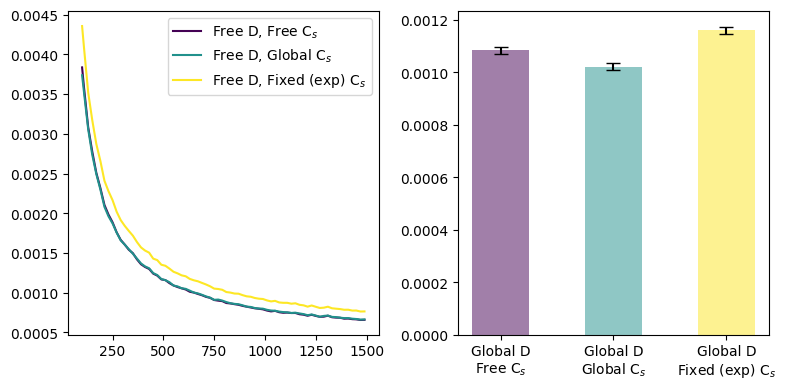

In [28]:
# ---- Plotting ----
# -- Fixed D --
dglob_cfree = opt_dglobal['d_global']
dglob_cglob = opt_global['d_global']
dglob_cfixedm = res_mean_cs['d_global']
# - Errors - 
dgcf_sem = opt_dglobal['se_d']
dgcg_sem = opt_global['se_d']
dgcfm_sem = res_mean_cs['se_d_global']

# -- Per-timepoint D --
dfree_cfree = opt_free['d_per_t']
dfree_cglob = opt_csglobal['d_per_t']
dfree_cfixed = res_per_cs['d_per_t']

# -- Plot --
fig, ax = plt.subplots(1, 2, figsize = (8, 4))

cmap = plt.get_cmap('viridis')
n_fits = 3
x_pos = np.arange(n_fits)
colors = cmap(np.linspace(0, 1, n_fits))

fd = ax[0] # global d
gd = ax[1] # free d

dfcf = fd.plot(time[10:], dfree_cfree[10:],
       label = 'Free D, Free C$_s$',
              color = colors[0])
dfcg = fd.plot(time[10:], dfree_cglob[10:],
       label = 'Free D, Global C$_s$',
              color = colors[1])
dfcfixed = fd.plot(time[10:], dfree_cfixed[10:],
       label = 'Free D, Fixed (exp) C$_s$',
                  color = colors[2])
fd.legend()

gd.bar(x_pos,
       [dglob_cfree,
       dglob_cglob,
       dglob_cfixedm],
       yerr = [dgcf_sem, dgcg_sem, dgcfm_sem],
       color = colors,
      alpha = 0.5,
      capsize = 5,
      width = 0.5)
gd.set_xticks(x_pos)
gd.set_xticklabels([f"Global D\nFree C$_s$",
                   f"Global D\nGlobal C$_s$",
                   f"Global D\nFixed (exp) C$_s$"])

plt.tight_layout()
plt.show()

## 2. Shifting `valid_indices` to identify informative timepoints
- From (1), earlier timepoints give an unstable fitting of D and may introduce bias
- Excluding uninformative timepoints may give a more precise fitting of D
> **Objective**: See whether shifting `valid_indices` (fitted timepoints) would eventually lead to a stabilized fitted D

In [29]:
# --- Loading variables ---
# Per-timepoint experimental CS
exp_cs = first_row
res_per_cs = diff_csfixed(
    c_xt = conc, x = depth, time = time,
    cs_fixed = exp_cs)


Global D fit complete.
D = 1.155e-03, SE = 1.399e-05 (95%CI [1.128e-03, 1.183e-03]
Mean per-timepoint R2 = 0.9170

Per-timepoint D fit:
t = 10.0 s: Cs = 60.381, D = 3.585e-02, SE = 1.791e-03 (95% CI[3.224e-02, 3.947e-02]), R2 = 0.9862
t = 20.0 s: Cs = 60.436, D = 1.873e-02, SE = 9.075e-04 (95% CI[1.690e-02, 2.056e-02]), R2 = 0.9868
t = 30.0 s: Cs = 60.674, D = 1.263e-02, SE = 6.487e-04 (95% CI[1.132e-02, 1.394e-02]), R2 = 0.9853
t = 40.0 s: Cs = 60.764, D = 9.765e-03, SE = 4.908e-04 (95% CI[8.775e-03, 1.076e-02]), R2 = 0.9858
t = 50.0 s: Cs = 61.172, D = 7.908e-03, SE = 3.958e-04 (95% CI[7.109e-03, 8.707e-03]), R2 = 0.9860
t = 60.0 s: Cs = 61.230, D = 6.780e-03, SE = 3.512e-04 (95% CI[6.072e-03, 7.489e-03]), R2 = 0.9848
t = 70.0 s: Cs = 60.910, D = 5.946e-03, SE = 2.967e-04 (95% CI[5.347e-03, 6.545e-03]), R2 = 0.9859
t = 80.0 s: Cs = 60.888, D = 5.285e-03, SE = 2.684e-04 (95% CI[4.743e-03, 5.827e-03]), R2 = 0.9854
t = 90.0 s: Cs = 61.114, D = 4.793e-03, SE = 2.454e-04 (95% CI[4.298e-0

In [30]:
time

array([   0.,   10.,   20.,   30.,   40.,   50.,   60.,   70.,   80.,
         90.,  100.,  110.,  130.,  150.,  170.,  190.,  210.,  230.,
        250.,  270.,  290.,  310.,  330.,  350.,  370.,  390.,  410.,
        430.,  450.,  470.,  490.,  510.,  530.,  550.,  570.,  590.,
        610.,  630.,  650.,  670.,  690.,  710.,  730.,  750.,  770.,
        790.,  810.,  830.,  850.,  870.,  890.,  910.,  930.,  950.,
        970.,  990., 1010., 1030., 1050., 1070., 1090., 1110., 1130.,
       1150., 1170., 1190., 1210., 1230., 1250., 1270., 1290., 1310.,
       1330., 1350., 1370., 1390., 1410., 1430., 1450., 1470., 1490.])

In [31]:
len(time)

81